In [3]:
import numpy as np
import pandas as pd

In [4]:
h = 1.055e-34  # Planck's constant
c = 3e8  # Speed of light
k = 1.381e-23  # Boltzmann's constant
T = 298  # Temperature in Kelvin

In [5]:
# I_BB = ((2*h*(c**2)) / (lambda_**5)) * (1/(np.exp(((h*c)/(lambda_*k*T)) - 1)))

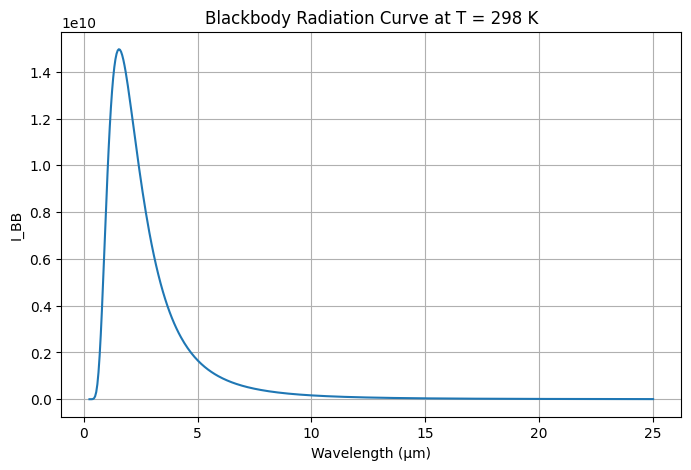

In [6]:
import matplotlib.pyplot as plt

# 生成lambda范围，单位为微米(um)
lambda_um = np.linspace(0.25, 25, 500)
lambda_ = lambda_um * 1e-6  # 转换为米(m)

# 计算I_BB
I_BB = ((2*h*(c**2)) / (lambda_**5)) * (1/(np.exp((h*c)/(lambda_*k*T)) - 1))

# 绘制曲线
plt.figure(figsize=(8, 5))
plt.plot(lambda_um, I_BB)
plt.xlabel('Wavelength (μm)')
plt.ylabel('I_BB')
plt.title('Blackbody Radiation Curve at T = {} K'.format(T))
plt.grid(True)
plt.show()

In [7]:
epsilon_df = pd.read_table("./data/E.txt", header=None, names=["lambda_um", "epsilon"])
epsilon_df.loc[:, "I_BB"] = ((2 * h * c**2) / (epsilon_df["lambda_um"] * 1e-6) ** 5) * (1 / (np.exp((h * c) / (epsilon_df["lambda_um"] * 1e-6 * k * T)) - 1))

In [8]:
epsilon_df.to_csv("./data/E_with_I_BB.txt", sep='\t', index=False)

In [9]:
epsilon = epsilon_df[(epsilon_df["lambda_um"] >= 8) & (epsilon_df["lambda_um"] <= 13)]

In [10]:
# epsilon.loc[:, "I_BB"] = ((2 * h * c**2) / (epsilon["lambda_um"] * 1e-6) ** 5) * (1 / (np.exp((h * c) / (epsilon["lambda_um"] * 1e-6 * k * T)) - 1))

In [11]:
numerator_trapz = np.trapezoid(epsilon['I_BB'] * epsilon['epsilon'], epsilon['lambda_um'])
denominator_trapz = np.trapezoid(epsilon['I_BB'], epsilon['lambda_um'])

result_trapz = numerator_trapz / denominator_trapz
result_trapz = round(result_trapz, 6)
result_trapz

np.float64(96.569898)